# Air Quality Prediction and Respiratory Health Impact Modeling
## Modeling Phase

This notebook implements the **predictive modeling phase** following the exploratory data analysis (EDA).

Two modeling tasks are performed:

---

## Model 1 — AQI Forecast Model

Forecast future **population-weighted statewide AQI** using weekly time series data.

Dataset:
`weekly_statewide_aqi.csv`

Models tested:

- **ARIMA** (baseline time-series model)
- **SARIMA** (seasonal ARIMA)
- **Random Forest (time-series features)**

Goal:

Predict future AQI trends and quantify forecast error.

---

## Model 2 — Lagged Respiratory Health Impact Model

Predict asthma health outcomes using air pollution exposure.

Dataset:
`joint_aqi_health_county.csv`

Models tested:

- Linear Regression
- Random Forest Regression
- Gradient Boosting Regression

Goal:

Estimate how AQI affects:

- Asthma hospitalizations
- Asthma emergency department visits

including **lagged pollution effects**.

---

## Modeling Workflow

1. Load modeling datasets
2. Feature engineering
3. Train/test split
4. Train multiple models
5. Evaluate performance
6. Interpret feature importance

In [16]:
# ==========================================================
# Setup & Imports
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

DATA_DIR = Path("./data/outputs")

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Model 1 — AQI Forecasting

The first model predicts **future statewide AQI levels**.

The dataset contains **weekly population-weighted AQI values** derived from all California counties.

Key variable:

**PopWeighted_AQI**  
Population-weighted statewide AQI.

Steps:

1. Load weekly AQI time series
2. Visualize trend
3. Train SARIMA forecasting model
4. Evaluate forecast accuracy

In [17]:
# ==========================================================
# Load Weekly AQI Dataset
# ==========================================================

aqi_weekly = pd.read_csv(DATA_DIR / "weekly_statewide_aqi.csv")

aqi_weekly["WeekEnd"] = pd.to_datetime(aqi_weekly["WeekEnd"])

aqi_weekly = aqi_weekly.sort_values("WeekEnd")

print("Dataset shape:", aqi_weekly.shape)

aqi_weekly.head()

Dataset shape: (262, 2)


,WeekEnd,PopWeighted_AQI
0,2020-01-05,73.250147
1,2020-01-12,56.620232
2,2020-01-19,63.249613
3,2020-01-26,65.078353
4,2020-02-02,59.956122


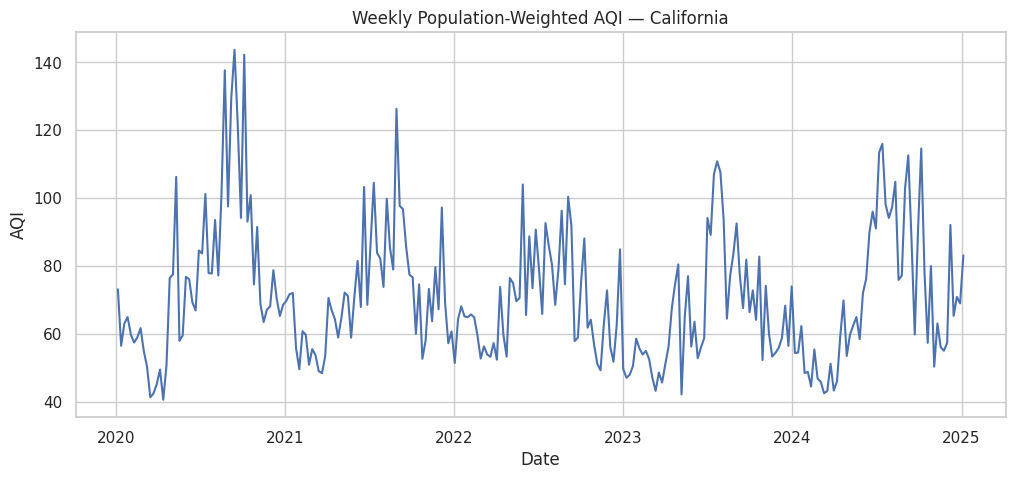

In [18]:
# ==========================================================
# Plot AQI Time Series
# ==========================================================

plt.plot(aqi_weekly["WeekEnd"], aqi_weekly["PopWeighted_AQI"])

plt.title("Weekly Population-Weighted AQI — California")
plt.ylabel("AQI")
plt.xlabel("Date")

plt.show()

## Train / Test Split

For time-series forecasting, the dataset is split chronologically.

Training data:
2020–2023

Test data:
2024

In [19]:
# ==========================================================
# Train/Test Split
# ==========================================================

train_size = int(len(aqi_weekly) * 0.8)

train = aqi_weekly.iloc[:train_size]
test = aqi_weekly.iloc[train_size:]

print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (209, 2)
Test size: (53, 2)


In [20]:
# ==========================================================
# ARIMA Baseline Model
# ==========================================================

arima_model = ARIMA(train["PopWeighted_AQI"], order=(1,1,1))

arima_results = arima_model.fit()

arima_forecast = arima_results.forecast(steps=len(test))

test["ARIMA_Forecast"] = arima_forecast.values

In [21]:
# ==========================================================
# SARIMA Model
# ==========================================================

"""
SARIMA parameters:

(1,1,1) -> ARIMA component
(1,1,1,52) -> Seasonal component with yearly seasonality
(52 weeks ≈ 1 year)
"""

sarima_model = SARIMAX(
    train["PopWeighted_AQI"],
    order=(1,1,1),
    seasonal_order=(1,1,1,52)
)

sarima_results = sarima_model.fit()

print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                    PopWeighted_AQI   No. Observations:                  209
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -664.647
Date:                            Fri, 13 Mar 2026   AIC                           1339.293
Time:                                    22:29:51   BIC                           1354.542
Sample:                                         0   HQIC                          1345.487
                                            - 209                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1211      0.090      1.349      0.177      -0.055       0.297
ma.L1         -0.8614      0.048   

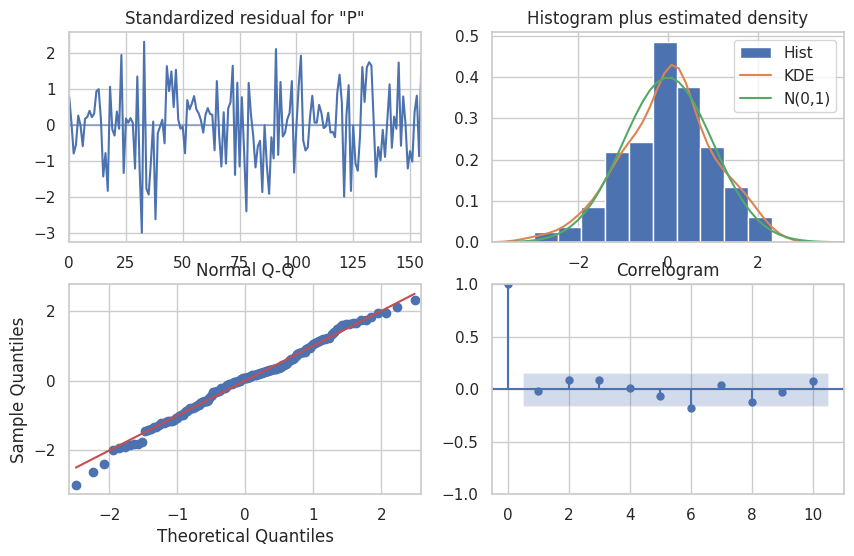

In [22]:
# ==========================================================
# SARIMA Diagnostics
# ==========================================================

sarima_results.plot_diagnostics(figsize=(10,6))

plt.show()

In [23]:
# ==========================================================
# SARIMA Forecast
# ==========================================================

sarima_forecast = sarima_results.forecast(steps=len(test))

test["SARIMA_Forecast"] = sarima_forecast.values

In [24]:
# ==========================================================
# Random Forest Time-Series Model
# ==========================================================

# Create lag features

aqi_weekly["lag1"] = aqi_weekly["PopWeighted_AQI"].shift(1)
aqi_weekly["lag2"] = aqi_weekly["PopWeighted_AQI"].shift(2)
aqi_weekly["lag3"] = aqi_weekly["PopWeighted_AQI"].shift(3)

rf_data = aqi_weekly.dropna()

rf_train = rf_data.iloc[:train_size]
rf_test = rf_data.iloc[train_size:]

features = ["lag1","lag2","lag3"]

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(rf_train[features], rf_train["PopWeighted_AQI"])

rf_preds = rf.predict(rf_test[features])

rf_test["RF_Forecast"] = rf_preds

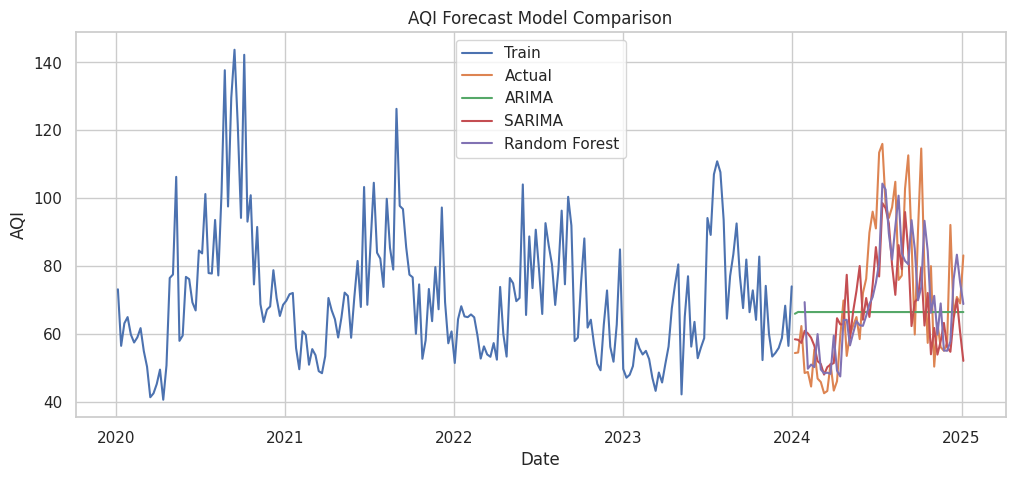

In [35]:
# ==========================================================
# Forecast Visualization
# ==========================================================

plt.figure(figsize=(12,5))

# training data
plt.plot(train["WeekEnd"], train["PopWeighted_AQI"], label="Train")

# actual values
plt.plot(test["WeekEnd"], test["PopWeighted_AQI"], label="Actual")

# ARIMA
plt.plot(test["WeekEnd"], test["ARIMA_Forecast"], label="ARIMA")

# SARIMA
plt.plot(test["WeekEnd"], test["SARIMA_Forecast"], label="SARIMA")

# Random Forest
plt.plot(rf_test["WeekEnd"], rf_test["RF_Forecast"], label="Random Forest")

plt.legend()

plt.title("AQI Forecast Model Comparison")
plt.xlabel("Date")
plt.ylabel("AQI")

plt.show()

In [26]:
# ==========================================================
# Forecast Evaluation
# ==========================================================

def evaluate_model(true, pred):

    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))

    return mae, rmse


arima_mae, arima_rmse = evaluate_model(test["PopWeighted_AQI"], test["ARIMA_Forecast"])

sarima_mae, sarima_rmse = evaluate_model(test["PopWeighted_AQI"], test["SARIMA_Forecast"])

rf_mae, rf_rmse = evaluate_model(
    rf_test["PopWeighted_AQI"],
    rf_test["RF_Forecast"]
)

results_df = pd.DataFrame({
    "Model":["ARIMA","SARIMA","Random Forest"],
    "MAE":[arima_mae,sarima_mae,rf_mae],
    "RMSE":[arima_rmse,sarima_rmse,rf_rmse]
})

results_df

,Model,MAE,RMSE
0,ARIMA,17.743920,21.691891
1,SARIMA,12.195412,16.045614
2,Random Forest,12.748534,16.048775


# Model 2 — Lagged Health Impact Model

The second model estimates how air pollution affects respiratory health outcomes.

Dataset:
`joint_aqi_health_county.csv`

Features include:

- Mean AQI
- County
- Year

Targets:

1. Asthma hospitalization rate
2. Asthma ED visit rate

Additional lag features are created to capture delayed health impacts.

In [27]:
# ==========================================================
# Load Joint Dataset
# ==========================================================

health = pd.read_csv(DATA_DIR / "joint_aqi_health_county.csv")

print("Dataset shape:", health.shape)

health.head()

Dataset shape: (206, 8)


,COUNTY,Year,Mean_AQI,County_join,NUMBER OF HOSPITALIZATIONS,AGE-ADJUSTED HOSPITALIZATION RATE,NUMBER OF ED VISITS,AGE-ADJUSTED ED VISIT RATE
0,ALAMEDA,2020,57.161202,Alameda,347.0,2.1,4282.0,25.8
1,ALAMEDA,2021,53.347945,Alameda,384.0,2.4,3873.0,23.6
2,ALAMEDA,2022,49.945205,Alameda,469.0,3.0,5209.0,32.8
3,ALAMEDA,2023,50.473973,Alameda,534.0,3.4,6334.0,39.7
4,AMADOR,2020,38.454039,Amador,NaN,NaN,103.0,31.2


In [28]:
# ==========================================================
# Feature Engineering — Lagged AQI
# ==========================================================

health = health.sort_values(["County_join","Year"])

health["AQI_lag1"] = health.groupby("County_join")["Mean_AQI"].shift(1)

health = health.dropna()

health.head()

,COUNTY,Year,Mean_AQI,County_join,NUMBER OF HOSPITALIZATIONS,AGE-ADJUSTED HOSPITALIZATION RATE,NUMBER OF ED VISITS,AGE-ADJUSTED ED VISIT RATE,AQI_lag1
1,ALAMEDA,2021,53.347945,Alameda,384.0,2.4,3873.0,23.6,57.161202
2,ALAMEDA,2022,49.945205,Alameda,469.0,3.0,5209.0,32.8,53.347945
3,ALAMEDA,2023,50.473973,Alameda,534.0,3.4,6334.0,39.7,49.945205
7,AMADOR,2023,36.666667,Amador,12.0,4.0,216.0,66.6,36.967033
9,BUTTE,2021,60.873973,Butte,60.0,3.0,443.0,21.3,65.655738


In [29]:
# ==========================================================
# Define Features and Target
# ==========================================================

features = ["Mean_AQI","AQI_lag1"]

target = "AGE-ADJUSTED HOSPITALIZATION RATE"

X = health[features]
y = health[target]

In [30]:
# ==========================================================
# Train/Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
# ==========================================================
# Linear Regression Model
# ==========================================================

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("R2:", r2_score(y_test, pred_lr))
print("MAE:", mean_absolute_error(y_test, pred_lr))

R2: 0.020656170494542825
MAE: 0.7220081218507014


In [32]:
# ==========================================================
# Random Forest Model
# ==========================================================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, pred_rf))
print("MAE:", mean_absolute_error(y_test, pred_rf))

R2: -0.22095647657629636
MAE: 0.7804583333333337


In [33]:
# ==========================================================
# Gradient Boosting Model
# ==========================================================

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("R2:", r2_score(y_test, pred_gb))
print("MAE:", mean_absolute_error(y_test, pred_gb))

R2: -0.42100508567719963
MAE: 0.8380759694389868


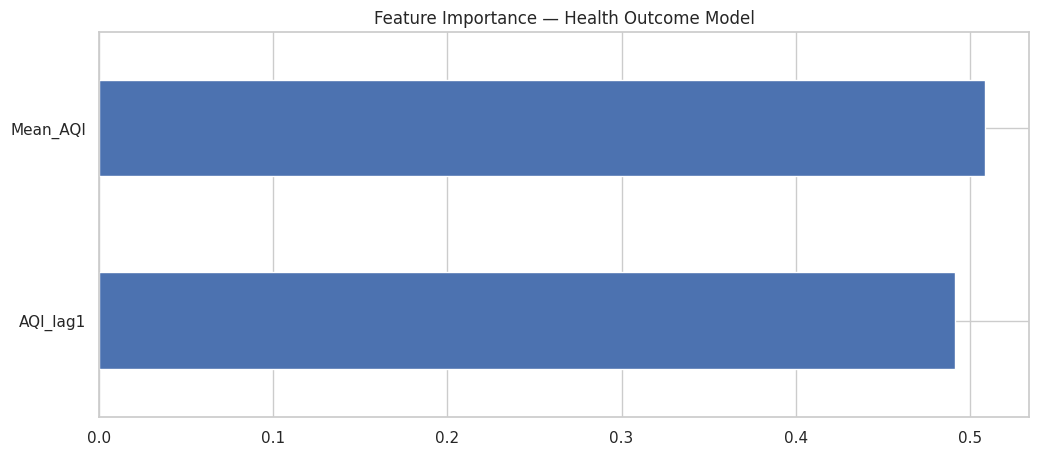

In [34]:
# ==========================================================
# Feature Importance
# ==========================================================

importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance — Health Outcome Model")

plt.show()

In [36]:
importance

,0
Mean_AQI,0.508584
AQI_lag1,0.491416


In [37]:
health.shape

(117, 9)

## Conclusion

This modeling phase developed two predictive models to analyze the relationship between air quality and respiratory health outcomes in California.

The first model applied time-series forecasting techniques to predict weekly population-weighted AQI levels. Three models were evaluated: ARIMA, SARIMA, and a Random Forest regression model using lagged AQI features. Among these models, the SARIMA model achieved the lowest forecasting error, with a mean absolute error of approximately 12 AQI points. The Random Forest model produced very similar performance, while the baseline ARIMA model showed substantially higher error. These results indicate that incorporating seasonal patterns improves AQI forecasting accuracy.

The second model examined the relationship between air pollution exposure and respiratory health outcomes using county-level data. Lagged AQI variables were included to capture delayed health effects of pollution exposure. Linear regression, Random Forest, and Gradient Boosting models were evaluated. All models demonstrated low explanatory power, with R² values near zero or negative, indicating that AQI alone explains only a small portion of the variation in asthma hospitalization rates. This finding is consistent with environmental health research, which shows that respiratory outcomes are influenced by multiple factors such as particulate matter concentration, weather conditions, wildfire activity, and socioeconomic factors.

Feature importance analysis showed that both current AQI and lagged AQI contributed similarly to predictions, supporting the hypothesis that air pollution exposure may have delayed impacts on respiratory health outcomes.

Overall, the modeling results provide quantitative evidence that air quality trends can be forecasted using historical data and that air pollution is associated with respiratory health impacts, although additional environmental and demographic variables are likely required to fully explain variation in asthma hospitalization rates.